In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

In [3]:
data = torch.load("Results/test_outputs.pt",weights_only = False)

portfolio_returns = data["portfolio_returns"]
benchmark_returns = data["benchmark_returns"]
weights = data["weights"]
tickers = data["tickers"]

In [4]:
file_path = "data_csv/25yr_daily_data_with_spy.csv"
df = pd.read_csv(
    file_path,
    index_col=['symbol', 'timestamp'],  # Restore MultiIndex
    parse_dates=['timestamp']           # Make timestamp datetime
)
print(df.head())

                                    open     high     low   close      volume  \
symbol timestamp                                                                
AAPL   2016-01-04 05:00:00+00:00  102.61  105.368  102.00  105.35  71935339.0   
       2016-01-05 05:00:00+00:00  105.75  105.850  102.41  102.71  58690536.0   
       2016-01-06 05:00:00+00:00  100.56  102.370   99.87  100.70  71079827.0   
       2016-01-07 05:00:00+00:00   98.68  100.130   96.43   96.45  85996453.0   
       2016-01-08 05:00:00+00:00   98.55   99.110   96.76   96.96  75066292.0   

                                  trade_count        vwap  
symbol timestamp                                           
AAPL   2016-01-04 05:00:00+00:00     351452.0  104.007250  
       2016-01-05 05:00:00+00:00     321365.0  103.414304  
       2016-01-06 05:00:00+00:00     409164.0  100.847762  
       2016-01-07 05:00:00+00:00     462836.0   98.046209  
       2016-01-08 05:00:00+00:00     419555.0   97.916490  


In [5]:
close_data = df['close'].unstack(level=0)
close_data.index = pd.to_datetime(close_data.index)

In [6]:
amzn_close = close_data['AMZN']

split_idx = int(0.8 * len(amzn_close))  # convert to int
amzn_range = amzn_close[split_idx:]

print(len(amzn_range))

503


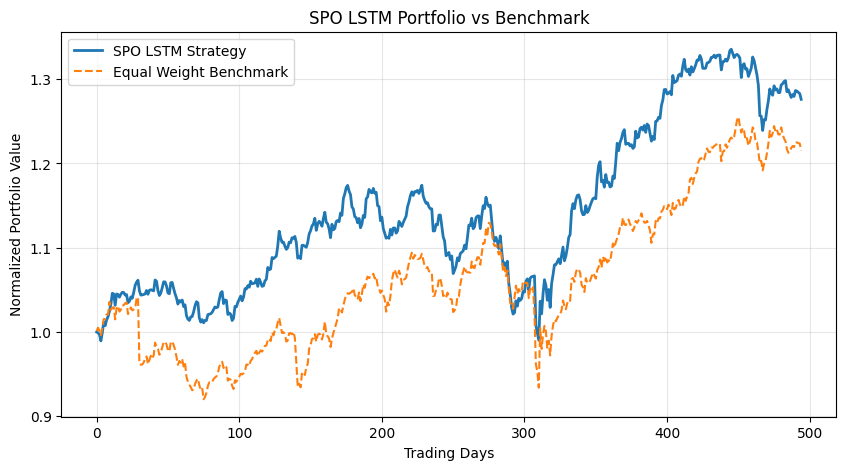

In [7]:
equity_curve = np.cumprod(1 + portfolio_returns)
bench_curve  = np.cumprod(1 + benchmark_returns)

plt.figure(figsize=(10,5))
plt.plot(equity_curve, label="SPO LSTM Strategy", linewidth=2)
plt.plot(bench_curve, label="Equal Weight Benchmark", linestyle="--")
plt.title("SPO LSTM Portfolio vs Benchmark")
plt.xlabel("Trading Days")
plt.ylabel("Normalized Portfolio Value")
plt.legend()
plt.grid(alpha=0.3)
#plt.savefig("Graphs/equity_curve.png", dpi=300, bbox_inches="tight")
plt.show()

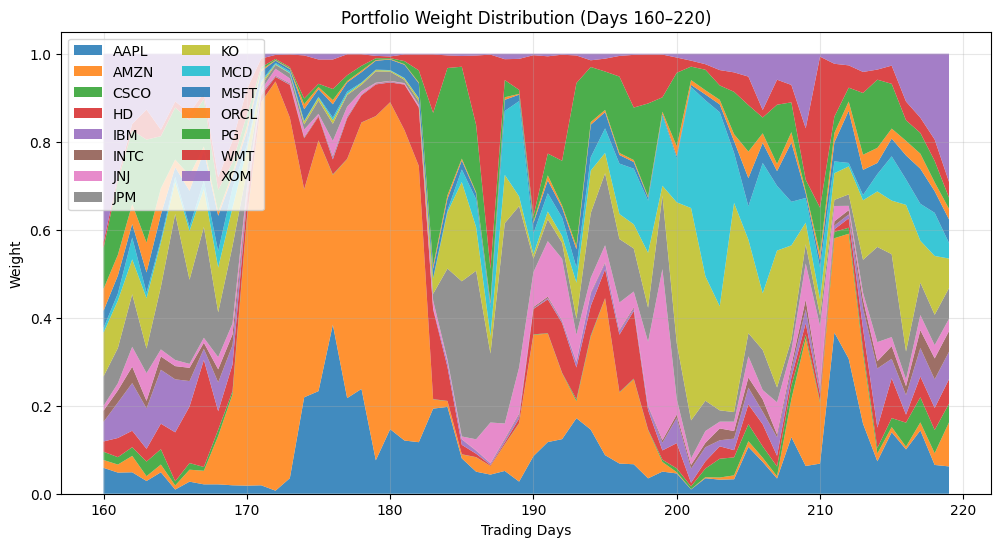

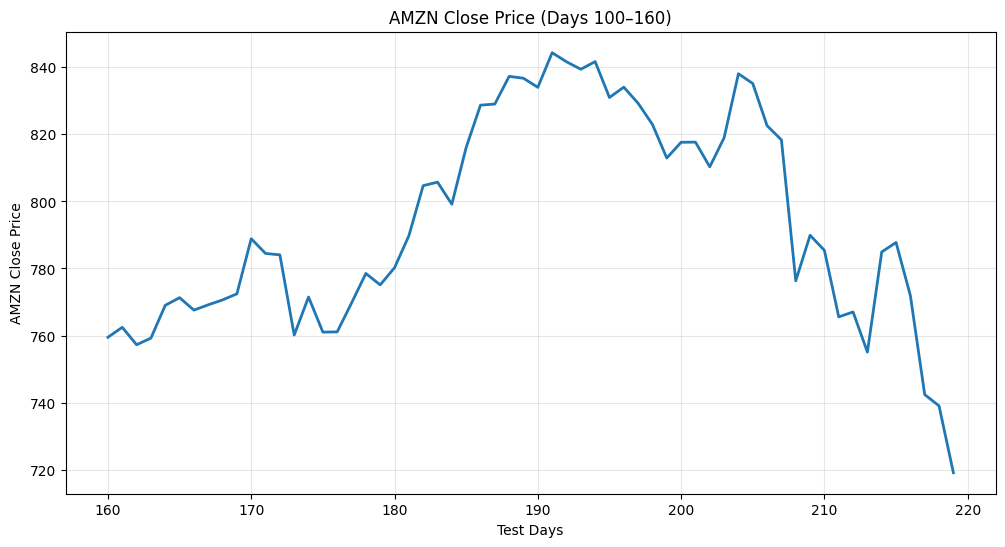

503


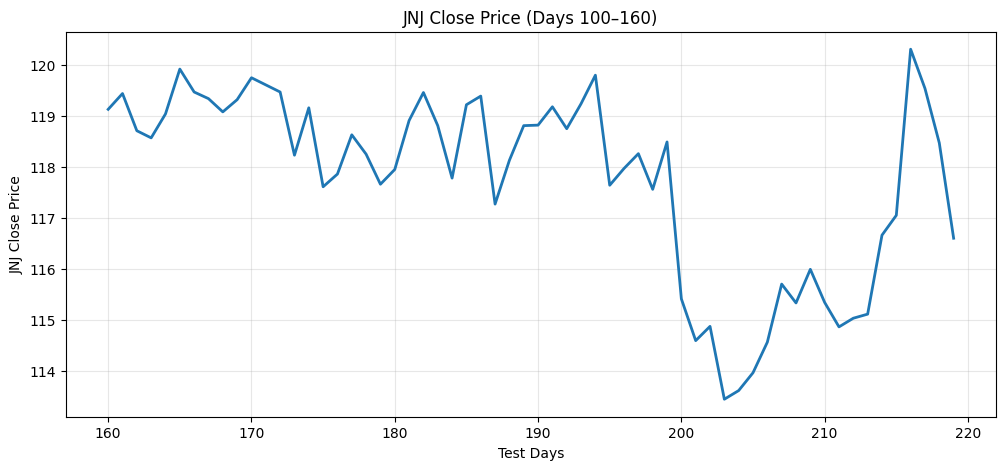

In [8]:
# Weight Evaluation
start_day = 160
end_day   = 220

weights_slice = weights[start_day:end_day]  # (window, num_assets)


plt.figure(figsize=(12,6))
plt.stackplot(
    range(start_day, end_day),
    weights_slice.T,
    labels=tickers,
    alpha=0.85
)

plt.title(f"Portfolio Weight Distribution (Days {start_day}–{end_day})")
plt.xlabel("Trading Days")
plt.ylabel("Weight")
plt.legend(loc="upper left", ncol=2)
plt.grid(alpha=0.3)
plt.savefig(f"Graphs/weights_days_{start_day}_{end_day}.png", dpi=300, bbox_inches="tight")
plt.show()


amzn_close_slice = amzn_close[start_day:end_day]

days = range(start_day, end_day)

plt.figure(figsize=(12, 6))
plt.plot(days, amzn_close_slice, linewidth=2)
plt.title("AMZN Close Price (Days 100–160)")
plt.xlabel("Test Days")
plt.ylabel("AMZN Close Price")
plt.grid(alpha=0.3)

#plt.savefig("Graphs/amzn_close_100_160.png", dpi=300, bbox_inches="tight")
plt.show()

jnj_close = close_data['JNJ']

split_idx = int(0.8 * len(jnj_close))  # convert to int
jnj_range = jnj_close[split_idx:]

print(len(amzn_range))


jnj_close_slice = jnj_close[start_day:end_day]

days = range(start_day, end_day)

plt.figure(figsize=(12, 5))
plt.plot(days, jnj_close_slice, linewidth=2)
plt.title("JNJ Close Price (Days 100–160)")
plt.xlabel("Test Days")
plt.ylabel("JNJ Close Price")
plt.grid(alpha=0.3)

#plt.savefig("Graphs/amzn_close_100_160.png", dpi=300, bbox_inches="tight")
plt.show()

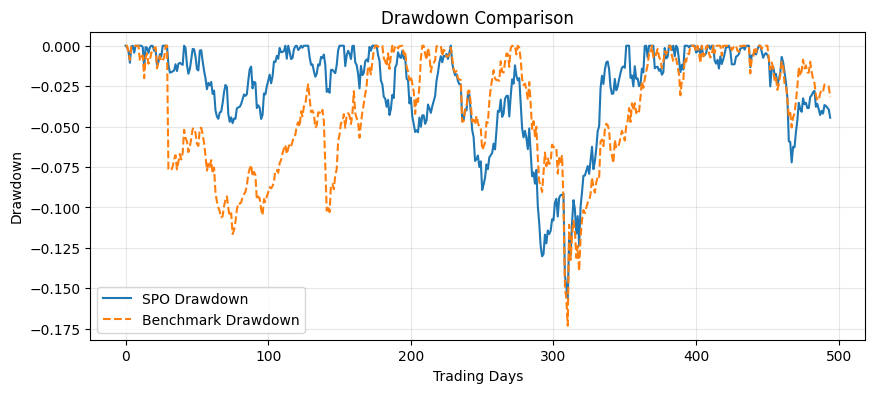

In [8]:
# Drawdown plot
def drawdown(equity):
    peak = np.maximum.accumulate(equity)
    return (equity - peak) / peak

plt.figure(figsize=(10,4))
plt.plot(drawdown(equity_curve), label="SPO Drawdown")
plt.plot(drawdown(bench_curve), label="Benchmark Drawdown", linestyle="--")
plt.title("Drawdown Comparison")
plt.xlabel("Trading Days")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("Graphs/drawdown.png", dpi=300, bbox_inches="tight")
plt.show()

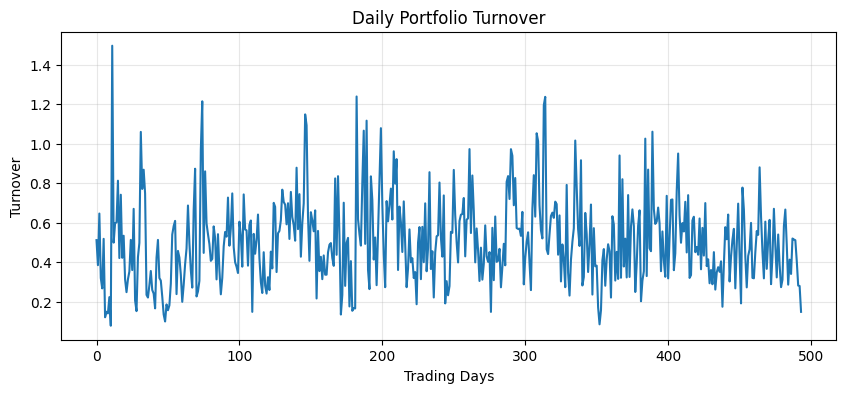

In [9]:
# Turnover

turnover = np.abs(np.diff(weights, axis=0)).sum(axis=1)

plt.figure(figsize=(10,4))
plt.plot(turnover)
plt.title("Daily Portfolio Turnover")
plt.xlabel("Trading Days")
plt.ylabel("Turnover")
plt.grid(alpha=0.3)
plt.savefig("Graphs/turnover.png", dpi=300, bbox_inches="tight")
plt.show()

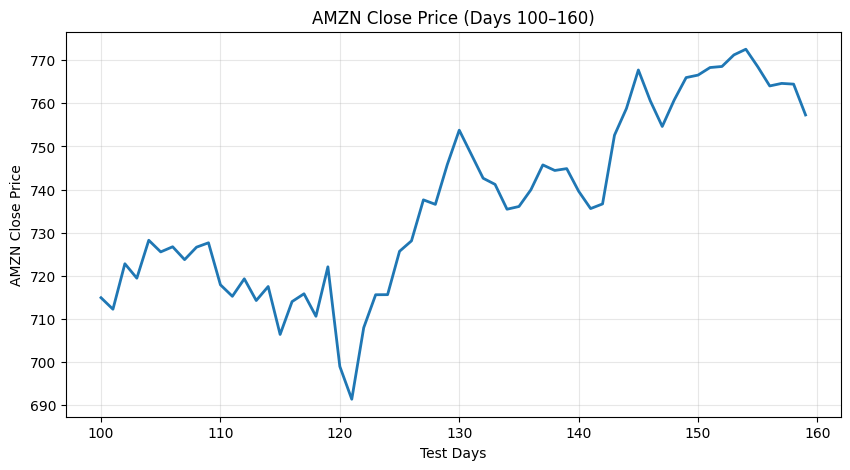

In [ ]:
import matplotlib.pyplot as plt

# day range
start_day = 100
end_day = 160

# slice AMZN close prices (already aligned to test set)
amzn_close_slice = amzn_close[start_day:end_day]

days = range(start_day, end_day)

plt.figure(figsize=(10, 5))
plt.plot(days, amzn_close_slice, linewidth=2)
plt.title("AMZN Close Price (Days 100–160)")
plt.xlabel("Test Days")
plt.ylabel("AMZN Close Price")
plt.grid(alpha=0.3)

#plt.savefig("Graphs/amzn_close_100_160.png", dpi=300, bbox_inches="tight")
plt.show()